# Tutorial de NPCore

Este notebook muestra cómo instalar y usar NPCore para crear NPCs con toma de decisiones, interacción y simulación.

In [1]:
!pip install npcore

In [2]:
from npcore import Brain, NPC, Environment
from npcore.environment import Environment
!pip install matplotlib

In [3]:
brain = Brain()

def idle_rule(context):
    return {"walk": 0.5, "rest": 0.5}

brain.add_rule("idle", idle_rule)

npc = NPC("Guard", brain)
npc.set_state("idle")

env = Environment()
env.add_npc(npc)

results = env.step()
results

[('Guard', 'walk')]

In [4]:
brain = Brain()

def idle_rule(context):
    return {"wait": 1.0}

brain.add_rule("idle", idle_rule)

npc1 = NPC("Guard", brain)
npc2 = NPC("Villager", brain)

npc1.set_state("idle")
npc2.set_state("idle")

npc1.set_position(0, 0)
npc2.set_position(1, 0)

env = Environment()
env.add_npc(npc1)
env.add_npc(npc2)

env.step()

[('Guard', 'wait'),
 ('message', 'Guard says hello to Villager'),
 ('Villager', 'wait'),
 ('message', 'Villager says hello to Guard')]

In [5]:
brain = Brain()

def idle_rule(context):
    return {"wait": 1.0}

def react_rule(npc, context):
    if "danger" in context.get("events", []):
        return {"run": 3.0, "defend": 1.0}
    return {"wait": 1.0}

brain.add_rule("idle", idle_rule)
brain.add_rule("react", react_rule)

guard = NPC("Guard", brain)
guard.set_state("react")
guard.set_group("guards")
guard.set_rank("leader")
guard.set_position(0, 0)
guard.set_goal("survive")
guard.set_emotion("fear", 0.5)

villager = NPC("Villager", brain)
villager.set_state("idle")
villager.set_group("villagers")
villager.set_position(1, 0)

scout = NPC("Scout", brain)
scout.set_state("react")
scout.set_group("guards")
scout.set_position(0, 1)
scout.set_emotion("fear", 0.2)

env = Environment()
env.add_npc(guard)
env.add_npc(villager)
env.add_npc(scout)

env.trigger_event("danger")
history = env.run(5)

history, env.summary()

([[('Guard', 'wait'),
   ('message', 'Guard says hello to Villager'),
   ('message', 'Guard says hello to Scout'),
   ('Villager', 'wait'),
   ('message', 'Villager says hello to Guard'),
   ('Scout', 'wait'),
   ('message', 'Scout says hello to Guard')],
  [('Guard', 'wait'),
   ('message', 'Guard says hello to Villager'),
   ('message', 'Guard says hello to Scout'),
   ('Villager', 'wait'),
   ('message', 'Villager says hello to Guard'),
   ('Scout', 'wait'),
   ('message', 'Scout says hello to Guard')],
  [('Guard', 'wait'),
   ('message', 'Guard says hello to Villager'),
   ('message', 'Guard says hello to Scout'),
   ('Villager', 'wait'),
   ('message', 'Villager says hello to Guard'),
   ('Scout', 'wait'),
   ('message', 'Scout says hello to Guard')],
  [('Guard', 'wait'),
   ('message', 'Guard says hello to Villager'),
   ('message', 'Guard says hello to Scout'),
   ('Villager', 'wait'),
   ('message', 'Villager says hello to Guard'),
   ('Scout', 'wait'),
   ('message', 'Scout 

In [6]:
import importlib
import npcore.environment

importlib.reload(npcore.environment)

from npcore.environment import Environment

import sys
sys.path.insert(0, "../src")

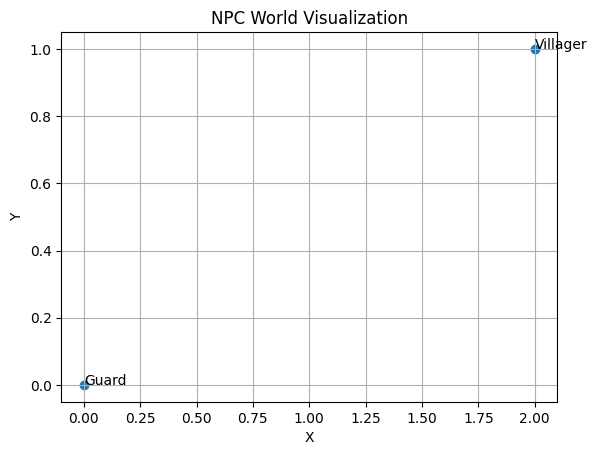

In [7]:
from npcore.environment import Environment
from npcore.npc import NPC
from npcore.brain import Brain

brain = Brain()

def idle_rule(context):
    return {"wait": 1.0}

brain.add_rule("idle", idle_rule)

env = Environment()

guard = NPC("Guard", brain)
villager = NPC("Villager", brain)

guard.set_position(0, 0)
villager.set_position(2, 1)

env.add_npc(guard)
env.add_npc(villager)

env.render_matplotlib()

In [8]:
env = Environment()
print(hasattr(env, "render_matplotlib"))

True


In [9]:
from npcore.environment import Environment

env = Environment()
print(hasattr(env, "render_matplotlib"))

True


In [10]:
from npcore.environment import Environment

env = Environment()
print(hasattr(env, "render_matplotlib"))

True
